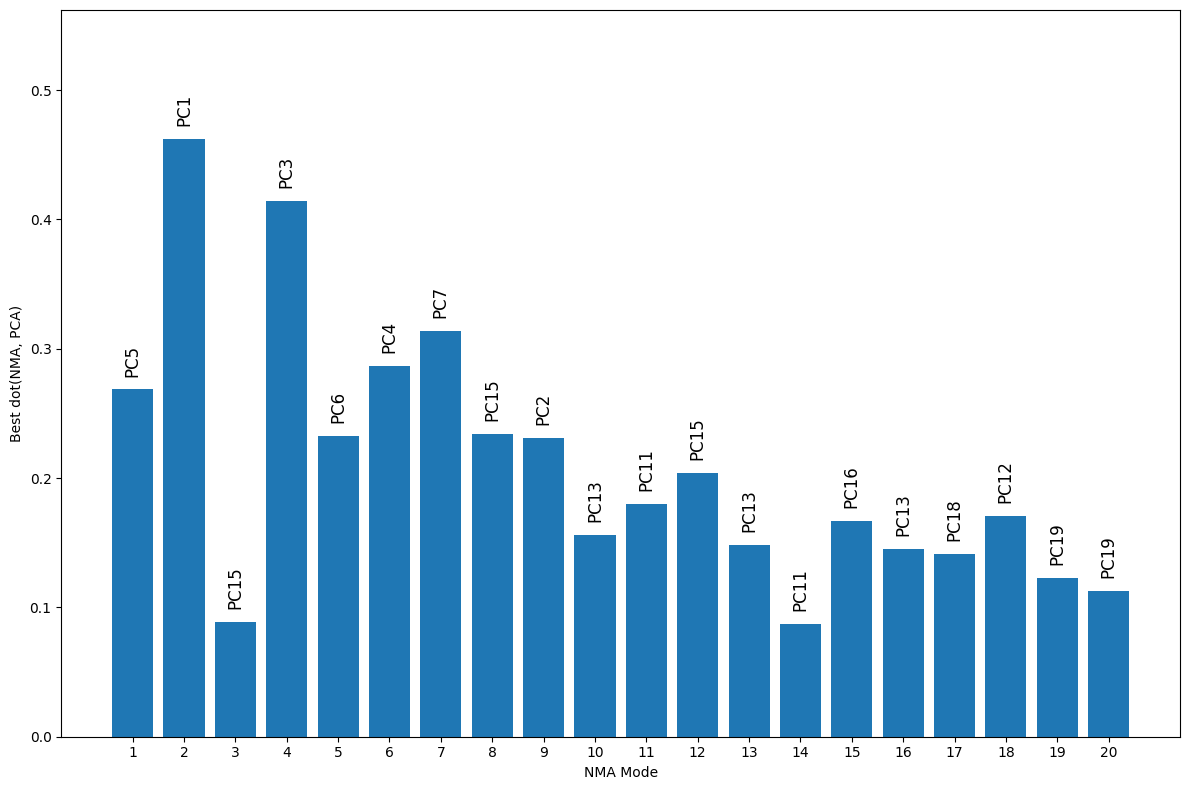

In [21]:
import numpy as np
import matplotlib.pyplot as plt

pdb = "7lak"

D = np.load(f"results/{pdb}/{pdb}_global_confusion_matrix.npy")
D = np.abs(D)

best_vals = D.max(axis=1)

best_pca = D.argmax(axis=1) + 1

labels = [f"PC{p}" for p in best_pca]

# x positions
x = np.arange(1, len(best_vals) + 1)

# figure
plt.figure(figsize=(12, 8))

bars = plt.bar(x, best_vals)

# add PCA labels above bars
for i, bar in enumerate(bars):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        labels[i],
        ha='center',
        va='bottom',
        fontsize=12,
        rotation=90
    )

plt.xticks(x)
plt.ylim(0, best_vals.max() + 0.1)

plt.xlabel("NMA Mode")
plt.ylabel("Best dot(NMA, PCA)")
#plt.title("Best PCA overlap per NMA mode")

plt.tight_layout()
plt.show()

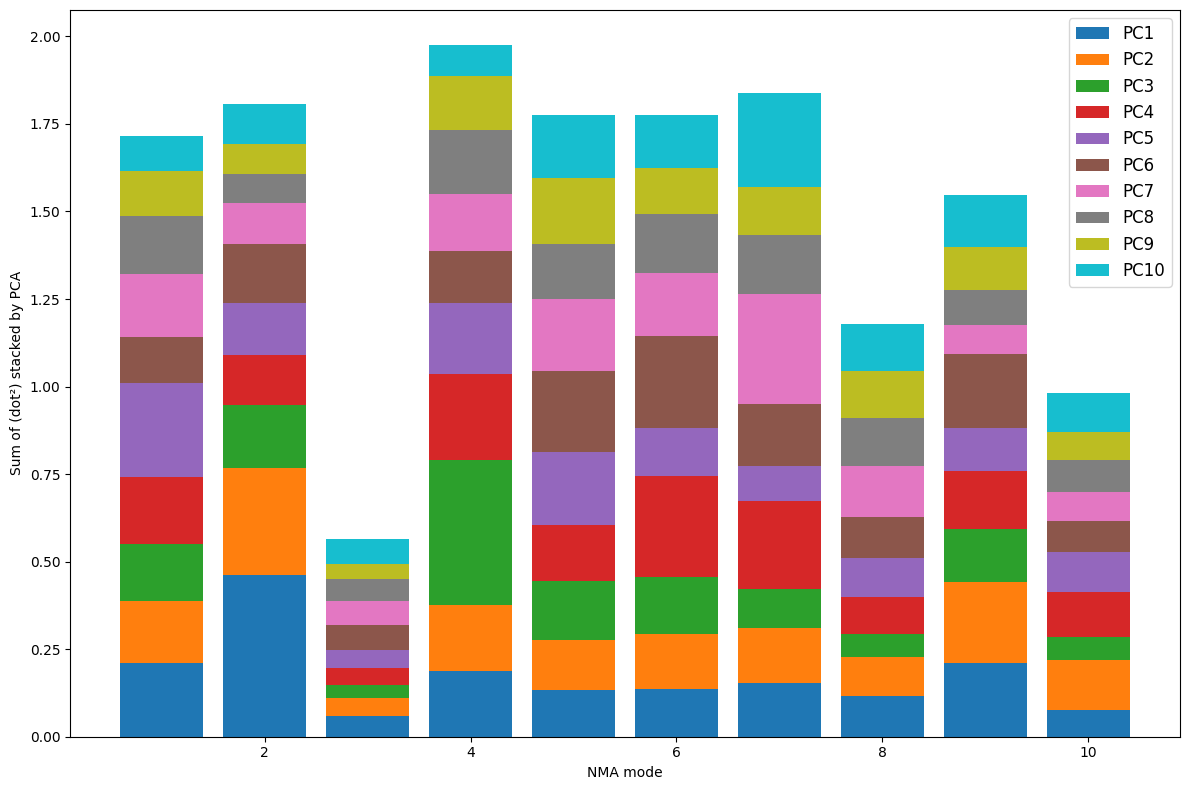

In [30]:


# squared overlaps
S = D

# choose modes
n_nma = 10
n_pca = 10

S = S[:n_nma, :n_pca]

x = np.arange(1, n_nma + 1)

plt.figure(figsize=(12,8))

bottom = np.zeros(n_nma)

for pc in range(n_pca):
    
    vals = S[:, pc]

    plt.bar(
        x,
        vals,
        bottom=bottom,
        label=f"PC{pc+1}"
    )

    bottom += vals

plt.xlabel("NMA mode")
plt.ylabel("Sum of (dot²) stacked by PCA")
#plt.title("Replica 0: NMA overlap with first 10 PCs (stacked)")

plt.legend(
    loc="upper right",
    fontsize=12
)

plt.tight_layout()
plt.show()

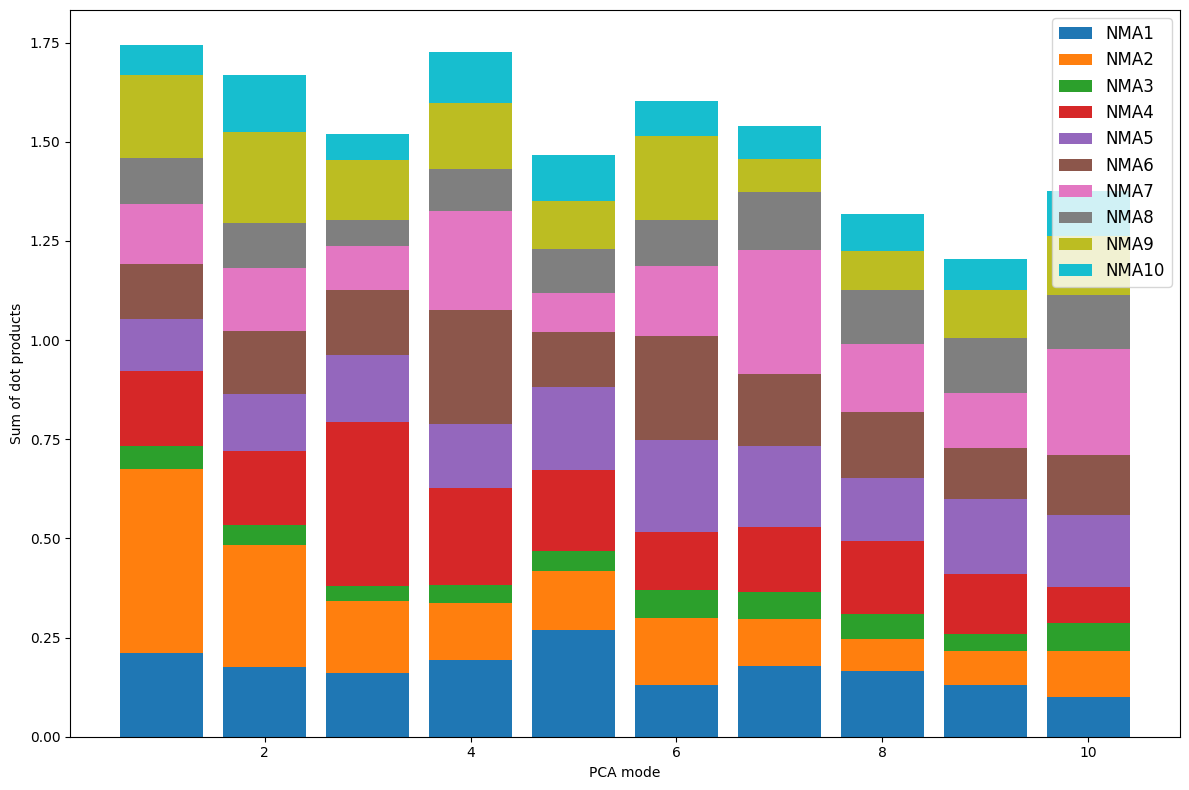

In [31]:
n_pca = 10

# NMA7–NMA16
nma_start = 1
nma_end = 10

# slice
S_sub = S[:10, :n_pca]

x = np.arange(1, n_pca + 1)

plt.figure(figsize=(12,8))

bottom = np.zeros(n_pca)

for i, nma_mode in enumerate(range(nma_start, nma_end + 1)):

    vals = S_sub[i]

    plt.bar(
        x,
        vals,
        bottom=bottom,
        label=f"NMA{nma_mode}"
    )

    bottom += vals

plt.xlabel("PCA mode")
plt.ylabel("Sum of dot products")

#plt.title(
    #f"PCA overlap with NMA{nma_start}–NMA{nma_end}"
#)

plt.legend(
    #bbox_to_anchor=(1.02, 1),
    loc="upper right",
    fontsize=12
)

plt.tight_layout()
plt.show()